In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [34]:
df = pd.read_csv('city_day.csv')


In [35]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [36]:
df.tail()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.0,Good


In [37]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())

Shape: (29531, 16)

Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
 City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Null Values:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [38]:
df['Date'] = pd.to_datetime(df['Date'])
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("\nCities in dataset:", df['City'].nunique())
print(df['City'].unique())

Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00

Cities in dataset: 26
['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']


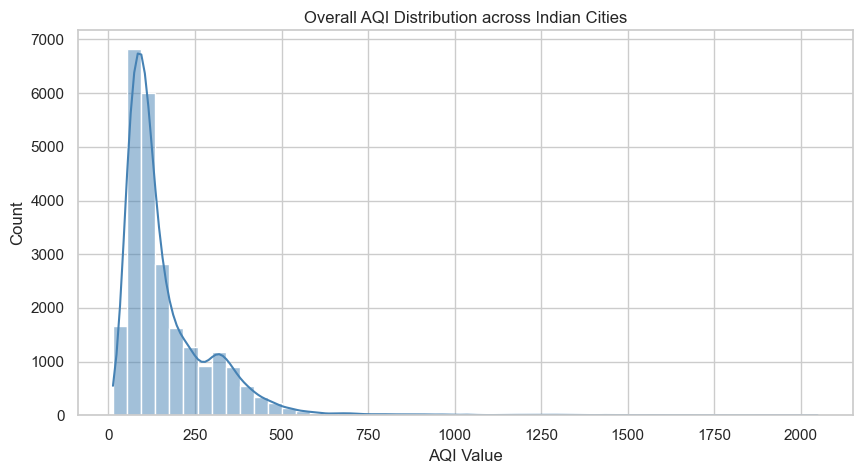

In [39]:
sns.histplot(df['AQI'].dropna(), bins=50, color='steelblue', kde=True)
plt.title("Overall AQI Distribution across Indian Cities")
plt.xlabel("AQI Value")
plt.ylabel("Count")
plt.show()

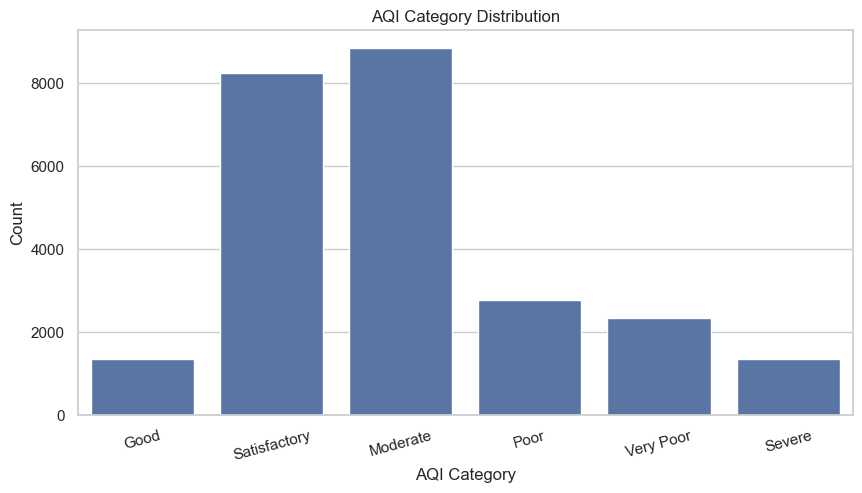

In [40]:
order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
colors = ['#2ecc71', '#a8e063', '#f9ca24', '#f0932b', '#e74c3c', '#6c0a0a']

sns.countplot(data=df, x='AQI_Bucket', order=order)
plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8520\949470499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_aqi.values, y=city_aqi.index, palette='Reds_r')


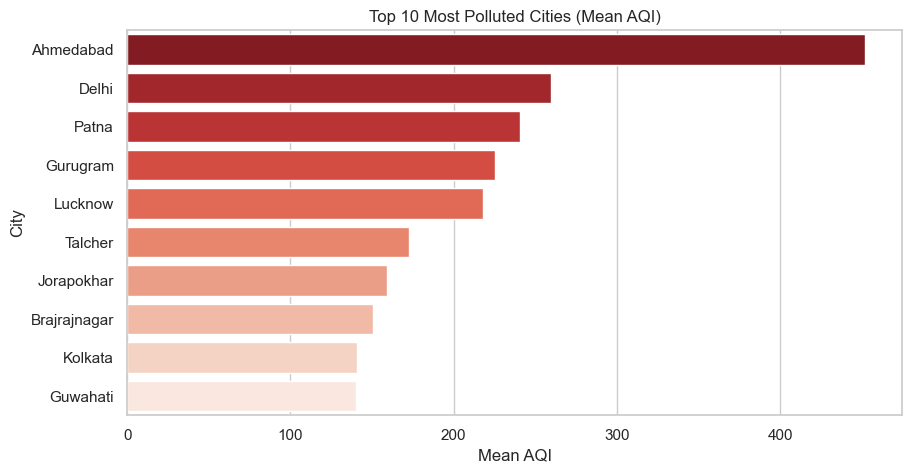

In [41]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=city_aqi.values, y=city_aqi.index, palette='Reds_r')
plt.title("Top 10 Most Polluted Cities (Mean AQI)")
plt.xlabel("Mean AQI")
plt.ylabel("City")
plt.show()

In [42]:
print(df['City'].unique())

['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']


Pune records: 2009


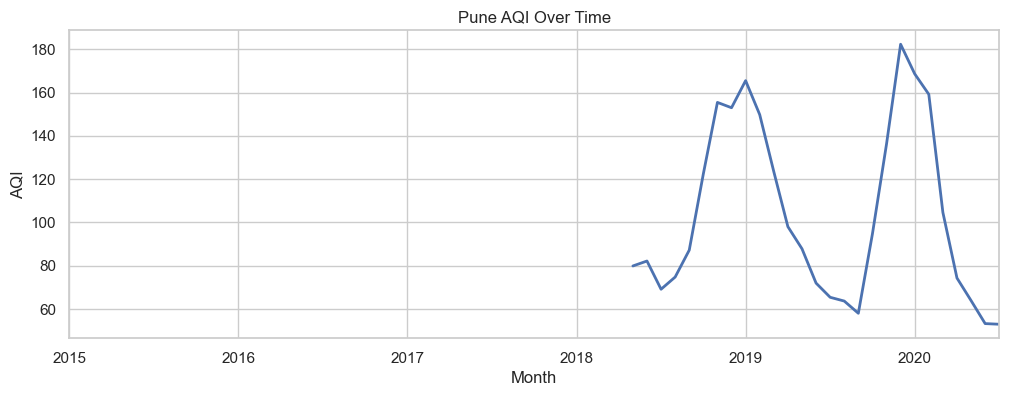

In [43]:
pune = df[df['City'] == 'Mumbai'].copy()
print("Pune records:", len(pune))

pune_monthly = pune.groupby(pune['Date'].dt.to_period('M'))['AQI'].mean()
pune_monthly.plot(figsize=(12,4), linewidth=2)
plt.title("Pune AQI Over Time")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.show()

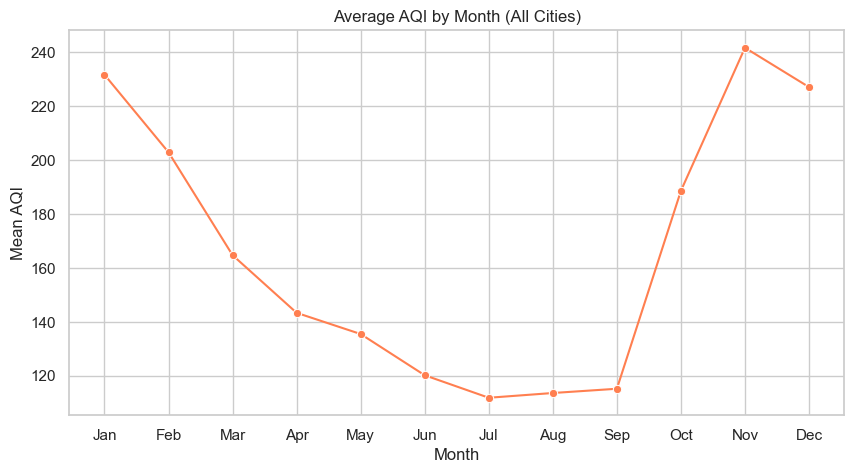

In [44]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['AQI'].mean()

sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', color='coral')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("Average AQI by Month (All Cities)")
plt.xlabel("Month")
plt.ylabel("Mean AQI")
plt.show()

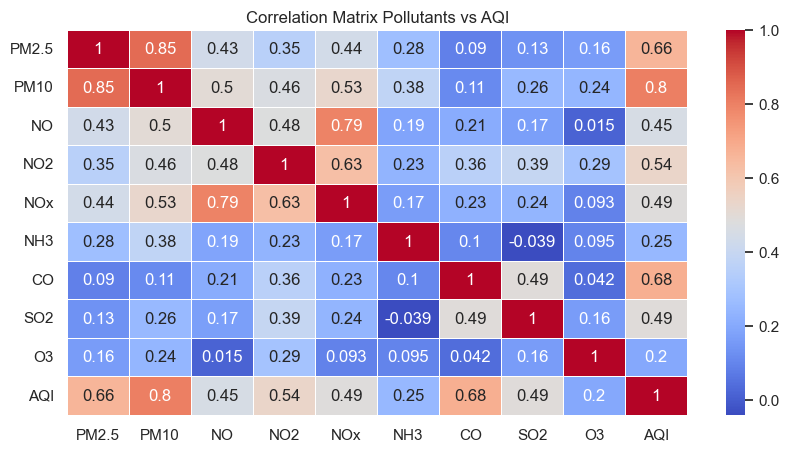

In [45]:
numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix Pollutants vs AQI")
plt.show()

In [46]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)
df[['Date', 'Year', 'Month', 'Day', 'Season']].head()

,Date,Year,Month,Day,Season
0,2015-01-01,2015,1,1,Winter
1,2015-01-02,2015,1,2,Winter
2,2015-01-03,2015,1,3,Winter
3,2015-01-04,2015,1,4,Winter
4,2015-01-05,2015,1,5,Winter


In [47]:
df[['Date', 'Year', 'Month', 'Day', 'Season']].tail()

,Date,Year,Month,Day,Season
29526,2020-06-27,2020,6,27,Monsoon
29527,2020-06-28,2020,6,28,Monsoon
29528,2020-06-29,2020,6,29,Monsoon
29529,2020-06-30,2020,6,30,Monsoon
29530,2020-07-01,2020,7,1,Monsoon


In [48]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
print(df[pollutant_cols].isnull().sum())
print("\nMissing AQI rows:", df['AQI'].isnull().sum())
print("Missing AQI_Bucket rows:", df['AQI_Bucket'].isnull().sum())

PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4185
NH3        10328
CO          2059
SO2         3854
O3          4022
Benzene     5623
Toluene     8041
Xylene     18109
dtype: int64

Missing AQI rows: 4681
Missing AQI_Bucket rows: 4681


In [49]:
for col in pollutant_cols:
    city_median = df.groupby('City')[col].transform('median')
    df[col] = df[col].fillna(city_median)
    df[col] = df[col].fillna(df[col].median())  # backup if whole city is missing

print(df[pollutant_cols].isnull().sum())

PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


In [50]:
before = df.shape[0]
df = df.dropna(subset=['AQI', 'AQI_Bucket'])
after = df.shape[0]
print(f"Dropped {before - after} rows with missing AQI/AQI_Bucket")
print("New shape:", df.shape)

Dropped 4681 rows with missing AQI/AQI_Bucket
New shape: (24850, 20)


###Insight ##
 Rather than filling missing pollutant values with a single global median, I used city-wise medians since pollution levels vary drastically between cities (e.g. Delhi vs Shillong). Rows missing the target variable (AQI) were dropped since they can't be used for training or evaluation.

In [51]:
order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
df['AQI_Bucket'] = pd.Categorical(df['AQI_Bucket'], categories=order, ordered=True)
df['AQI_Bucket_Code'] = df['AQI_Bucket'].cat.codes  

df[['AQI', 'AQI_Bucket', 'AQI_Bucket_Code']].head()

,AQI,AQI_Bucket,AQI_Bucket_Code
28,209.0,Poor,3
29,328.0,Very Poor,4
30,514.0,Severe,5
31,782.0,Severe,5
32,914.0,Severe,5


In [52]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
df['City_Code'] = le_city.fit_transform(df['City'])

le_season = LabelEncoder()
df['Season_Code'] = le_season.fit_transform(df['Season'])

df[['City', 'City_Code', 'Season', 'Season_Code']].head()

,City,City_Code,Season,Season_Code
28,Ahmedabad,0,Winter,3
29,Ahmedabad,0,Winter,3
30,Ahmedabad,0,Winter,3
31,Ahmedabad,0,Winter,3
32,Ahmedabad,0,Winter,3


In [53]:
feature_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
                 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'City_Code', 'Season_Code']

print("Features for modeling:", feature_cols)
print("\nNull check:\n", df[feature_cols].isnull().sum())
print("\nFinal shape:", df.shape)

Features for modeling: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'City_Code', 'Season_Code']

Null check:
 PM2.5          0
PM10           0
NO             0
NO2            0
NOx            0
NH3            0
CO             0
SO2            0
O3             0
Benzene        0
Toluene        0
Xylene         0
Year           0
Month          0
City_Code      0
Season_Code    0
dtype: int64

Final shape: (24850, 23)


In [54]:
print(df['AQI_Bucket'].value_counts())

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [55]:
feature_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
                 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'City_Code', 'Season_Code']

X = df[feature_cols]
y = df['AQI_Bucket_Code']

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (19880, 16)
Test size: (4970, 16)


In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_balanced.value_counts())

Before SMOTE: AQI_Bucket_Code
2    7084
1    6569
3    2226
4    1875
5    1067
0    1059
Name: count, dtype: int64

After SMOTE: AQI_Bucket_Code
1    7084
2    7084
3    7084
5    7084
4    7084
0    7084
Name: count, dtype: int64


In [58]:
X_reg = df[feature_cols]
y_reg = df['AQI']

In [59]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("Train size:", X_train_r.shape)
print("Test size:", X_test_r.shape)

Train size: (19880, 16)
Test size: (4970, 16)


In [60]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_lr = lr.predict(X_test_r)

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_r, y_train_r)
y_pred_rf = rf.predict(X_test_r)

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("**** Linear Regression ****")
print("MAE : ", round(mean_absolute_error(y_test_r, y_pred_lr), 2))
print("RMSE: ", round(np.sqrt(mean_squared_error(y_test_r, y_pred_lr)), 2))
print("R²  : ", round(r2_score(y_test_r, y_pred_lr), 2))

print("\n---- Random Forest ----")
print("MAE :", round(mean_absolute_error(y_test_r, y_pred_rf), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, y_pred_rf)), 2))
print("R²  :", round(r2_score(y_test_r, y_pred_rf), 2))

**** Linear Regression ****
MAE :  30.93
RMSE:  59.03
R²  :  0.81

---- Random Forest ----
MAE : 20.64
RMSE: 41.05
R²  : 0.91


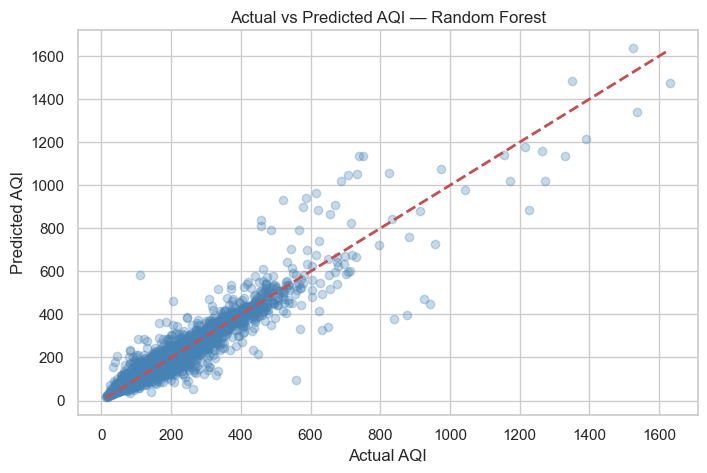

In [63]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, y_pred_rf, alpha=0.3, color='steelblue')
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI — Random Forest")
plt.show()

Insight
 Each dot is one test row. A perfect model would have all dots sitting on the red diagonal line. Dots close to the line = accurate predictions. Dots far away = errors.

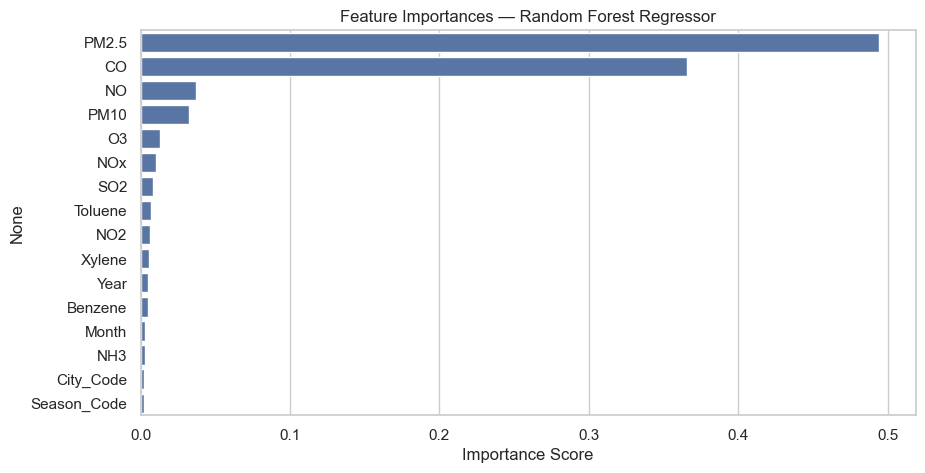

In [64]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances — Random Forest Regressor")
plt.xlabel("Importance Score")
plt.show()

Insight

 PM2.5 and PM10 will almost always be the top features — they are the primary contributors to AQI calculation. City and Season also matter, confirming that location and time of year affect pollution levels significantly.

In [65]:
X_cls = df[feature_cols]
y_cls = df['AQI_Bucket_Code']

In [66]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

print("Train size:", X_train_c.shape)
print("Test size:", X_test_c.shape)

Train size: (19880, 16)
Test size: (4970, 16)


In [67]:
X_train_c_bal, y_train_c_bal = smote.fit_resample(X_train_c, y_train_c)

print("Before SMOTE:", y_train_c.value_counts())
print("\nAfter SMOTE:", y_train_c_bal.value_counts())

Before SMOTE: AQI_Bucket_Code
2    7084
1    6569
3    2226
4    1875
5    1067
0    1059
Name: count, dtype: int64

After SMOTE: AQI_Bucket_Code
1    7084
2    7084
3    7084
5    7084
4    7084
0    7084
Name: count, dtype: int64


In [68]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(max_iter=1000, random_state=42)
lg.fit(X_train_c_bal, y_train_c_bal)
y_pred_lg = lg.predict(X_test_c)

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train_c_bal, y_train_c_bal)
y_pred_rfc = rfc.predict(X_test_c)

In [70]:
from sklearn.metrics import classification_report, accuracy_score

print("---- Logistic Regression ----")
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_lg), 2))
print(classification_report(y_test_c, y_pred_lg))

print("---- Random Forest ----")
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_rfc), 2))
print(classification_report(y_test_c, y_pred_rfc))

---- Logistic Regression ----
Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.33      0.82      0.47       282
           1       0.74      0.59      0.66      1655
           2       0.75      0.65      0.69      1745
           3       0.52      0.68      0.59       555
           4       0.73      0.72      0.72       462
           5       0.78      0.79      0.78       271

    accuracy                           0.65      4970
   macro avg       0.64      0.71      0.65      4970
weighted avg       0.70      0.65      0.66      4970

---- Random Forest ----
Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.74      0.77      0.76       282
           1       0.87      0.85      0.86      1655
           2       0.83      0.83      0.83      1745
           3       0.64      0.69      0.66       555
           4       0.77      0.76      0.76       462
           5       0.84      0.82      0.83     

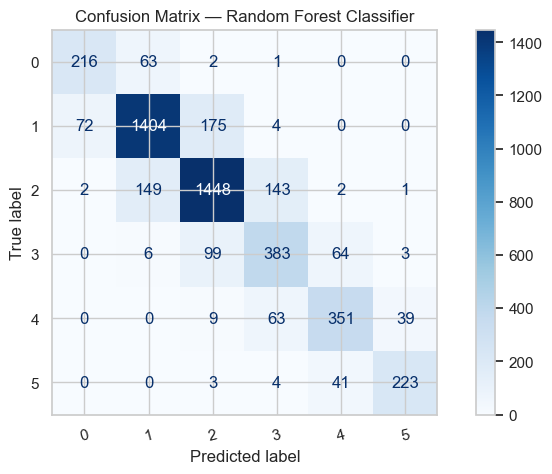

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test_c, y_pred_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest Classifier")
plt.xticks(rotation=15)
plt.show()

In [73]:
import pickle

# Save Random Forest Classifier (best model)
pickle.dump(rfc, open('aqi_model.pkl', 'wb'))

# Save label encoder for city
pickle.dump(le_city, open('le_city.pkl', 'wb'))

# Save label encoder for season
pickle.dump(le_season, open('le_season.pkl', 'wb'))

# Save feature columns
pickle.dump(feature_cols, open('columns.pkl', 'wb'))

print('Model and files saved!')

Model and files saved!
